In [25]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio
from matplotlib import pyplot as plt
from pyproj import Transformer
from rasterio.transform import Affine, from_bounds
from rasterio.warp import Resampling, reproject

import venti
from venti.log import get_logger
from venti.models import plate_motion

logger = get_logger("venti", enable_file_logging=False)

In [40]:
def make_point_grid(gdf: gpd.GeoDataFrame,
                   cell_size: float = 50000,
                   target_crs: str = "EPSG:4326") -> tuple[np.ndarray, np.ndarray]:
    """Create a regular point grid within a polygon GeoDataFrame.

    Parameters
    ----------
    gdf : GeoDataFrame
        Input polygon(s), assumed to be in EPSG:4326.
    cell_size : float, optional
        Spacing between points in meters (default: 50,000 = 50 km).
    target_crs : str, optional
        CRS for output grid (default: "EPSG:4326").

    Returns
    -------
    x : np.ndarray
        X coordinates of grid points (longitude if EPSG:4326).
    y : np.ndarray
        Y coordinates of grid points (latitude if EPSG:4326).

    Raises
    ------
    ValueError
        If input GeoDataFrame is empty or invalid.

    """
    if gdf.empty:
        msg = "Input GeoDataFrame is empty"
        raise ValueError(msg)

    if gdf.crs is None:
        logger.warning("No CRS defined for input GeoDataFrame, assuming EPSG:4326")
        gdf = gdf.set_crs("EPSG:4326")

    try:
        # Project polygon to UTM for accurate meter-based calculations
        utm_crs = gdf.estimate_utm_crs()
        gdf_proj = gdf.to_crs(utm_crs)
        logger.info(f"Projected to {utm_crs} for grid generation")

        # Get bounds
        minx, miny, maxx, maxy = gdf_proj.total_bounds
        logger.info(f"Bounds: {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}")

        # Calculate grid dimensions
        width = max(1, int(np.rint((maxx - minx) / cell_size)))
        length = max(1, int(np.rint((maxy - miny) / cell_size)))
        logger.info(f"Grid dimensions: {width} x {length} points")

        # Generate grid coordinates
        gridy, gridx = np.mgrid[maxy:miny:length*1j, minx:maxx:width*1j]

        # Transform back to target CRS
        transformer = Transformer.from_crs(utm_crs, target_crs, always_xy=True)
        x, y = transformer.transform(gridx, gridy)

        logger.info(f"Generated grid with {x.size} points")
        return x, y

    except Exception as e:
        logger.exception(f"Error generating grid: {e}")
        raise


def get_model_per_frame(frame_id: int,
                        output: str | Path = 'output',
                        plate: str = "NOAM",
                        itrf: int | str = 2014,
                        gia: str | None = None,
                        resampling_mode: Resampling = Resampling.bilinear) -> tuple[np.ndarray, np.ndarray]:
    # DISP frame database path
    data_path = Path(venti.__path__[0]).parents[1]

    # Set output dir
    output_dir = Path(output)
    output_dir.mkdir(exist_ok=True)

    # Output name
    output_name = output_dir / f"frame_{frame_id}_{plate}_ITRF{itrf}_rates.tif"

    # Validate inputs
    if itrf not in [2014, 2020]:
        msg = f"ITRF year must be 2014 or 2020, got {itrf}"
        raise ValueError(msg)

    # Check for required data files
    frame_file = data_path / "data/opera_disp_frame.geojson"
    if not frame_file.exists():
        msg = f"DISP frame database not found: {frame_file}"
        raise FileNotFoundError(msg)

    # Load DISP frame database
    logger.info(f"Loading DISP frame database from {frame_file}")
    disp_frame_db = gpd.read_file(frame_file)

    # Select specific frame
    selected_frame = disp_frame_db[disp_frame_db['fid'] == frame_id]
    if selected_frame.empty:
        available_fids = disp_frame_db['fid'].unique()
        msg = f"Frame ID {frame_id} not found. Available IDs: {available_fids}"
        raise ValueError(msg)
    logger.info(f"Selected frame {frame_id}")

    # Determine UTM CRS for the frame
    utm_crs = selected_frame.estimate_utm_crs()
    selected_frame_utm = selected_frame.to_crs(utm_crs)
    minx, miny, maxx, maxy = selected_frame_utm.total_bounds
    xs = np.arange(minx, maxx, 30)
    ys = np.arange(maxy, miny, -30)
    dst_transform = Affine(30, 0, minx, 0, -30, maxy)
    target_height, target_width = len(ys), len(xs)

    # Load ITRF PMM
    itrf_pmm = plate_motion.json_to_dataframe(plate_motion.load_itrf_json(date=itrf))
    pmm = itrf_pmm[itrf_pmm.plate == plate]

    if pmm.empty:
        available_plates = itrf_pmm['plate'].unique()
        msg = f"Plate '{plate}' not found. Available plates: {available_plates}"
        raise ValueError(msg)

    # Generate coarse grid for plate motion (10km spacing)
    grid_lons, grid_lats = make_point_grid(selected_frame, cell_size=10e3)
    grid_length, grid_width = grid_lons.shape
    src_transform = from_bounds(*selected_frame.total_bounds,
                                width=grid_width, height=grid_length)
    src_crs = selected_frame.crs

    # Model plate horizontal velocities
    logger.info("Modeling plate velocities")
    pmm_vel = plate_motion.model_plate_velocities(
        grid_lons.ravel(), grid_lats.ravel(),
        pmm.omega_x.iloc[0], pmm.omega_y.iloc[0], pmm.omega_z.iloc[0]
    )
    pmm_ve = pmm_vel[:, 0].reshape((grid_length, grid_width)) # East-West
    pmm_vn = pmm_vel[:, 1].reshape((grid_length, grid_width)) # North-South

    # Interpolate and repoject plate motion to DISP grid
    atr = {"rows":target_height, "cols":target_width}

    with rasterio.open(
            output_name, "w",
            height=atr["rows"], width=atr["cols"],
            count=2, dtype="float32", crs=utm_crs, transform=dst_transform,
            nodata=np.nan,
            compress='lzw', tiled=True, blockxsize=512, blockysize=512,
            predictor=2, interleave='band',
    ) as dst:
        dst.set_band_description(1, "North-South (mm/yr)")
        dst.set_band_description(2, "East-West (mm/yr)")

        # Interpolate PMM North-South
        logger.info(f"Writing plate NS rates: {output_name} [band: 1]")
        reproject(
            source=pmm_vn,
            destination=rasterio.band(dst, 1),
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=utm_crs,
            resampling=resampling_mode,
            dst_nodata=np.nan,
        )
        # Interpolate PMM East-West
        logger.info(f"Writing plate EW rates: {output_name} [band: 2]")
        reproject(
            source=pmm_ve,
            destination=rasterio.band(dst, 2),
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=utm_crs,
            resampling=resampling_mode,
            dst_nodata=np.nan,
        )

In [27]:
itrf=2014
frame_id=3060

disp_frame_db = gpd.read_file('data/opera_disp_frame.geojson')
na_disp_frame_db = disp_frame_db[disp_frame_db.is_north_america]

In [28]:
na_disp_frame_db[na_disp_frame_db.orbit_pass.str.startswith('DESC')].explore()

In [29]:
itrf14_pmm = plate_motion.json_to_dataframe(plate_motion.load_itrf_json(date=2014))
itrf14_pmm

,plate,name,omega_x,omega_y,omega_z
0,ANTA,Antarctic Plate,-0.0688,-0.0900,0.1874
1,ARAB,Arabian Plate,0.3205,-0.0378,0.4011
2,AUST,Australian Plate,0.4194,0.3284,0.3375
3,EURA,Eurasian Plate,-0.0235,-0.1476,0.2140
4,INDI,Indian Plate,0.3205,-0.0014,0.4038
5,NAZC,Nazca Plate,-0.0925,-0.4290,0.4508
6,NOAM,North American Plate,0.0066,-0.1928,-0.0176
7,NUBI,Nubian Plate,0.0274,-0.1704,0.2037
8,PCFC,Pacific Plate,-0.1135,0.2907,-0.6025
9,SOAM,South American Plate,-0.0751,-0.0835,-0.0389


In [30]:
pmm = itrf14_pmm[itrf14_pmm.plate=='NOAM']


# Use your model_plate_velocities function
predicted_velocities = plate_motion.model_plate_velocities(
    [-120, -121], [40, 41],
    pmm.omega_x, pmm.omega_y, pmm.omega_z,
)

ve_pred = predicted_velocities[:, 0]
vn_pred = predicted_velocities[:, 1]
ve_pred, vn_pred

(array([-13.15200398, -13.23977207]), array([-11.3517434 , -11.66687569]))

In [23]:
selected_fid = na_disp_frame_db[na_disp_frame_db.fid==frame_id]
selected_fid

,fid,epsg,is_land,is_north_america,relative_orbit_number,orbit_pass,xmin,ymin,xmax,ymax,geometry
3059,3060,32614,1,True,12,DESCENDING,225720,4090470,518610,4304280,"MULTIPOLYGON Z (((-100.15316 37.0918 0, -100.6..."


In [32]:
selected_fid.to_crs(selected_fid.estimate_utm_crs())

,fid,epsg,is_land,is_north_america,relative_orbit_number,orbit_pass,xmin,ymin,xmax,ymax,geometry
3059,3060,32614,1,True,12,DESCENDING,225720,4090470,518610,4304280,"MULTIPOLYGON Z (((397517.663 4105677.7 0, 3516..."


In [33]:
m = selected_fid.explore()
grid =make_point_grid(selected_fid, 10e3)
gpd.GeoDataFrame(geometry=gpd.points_from_xy(grid[0].ravel(), grid[1].ravel())).explore(m=m)

2025-09-17 10:44:14 | venti                | INFO     | Projected to EPSG:32614 for grid generation | taskName=Task-3 | message=Projected to EPSG:32614 for grid generation | asctime=2025-09-17 10:44:14
2025-09-17 10:44:14 | venti                | INFO     | Bounds: 230731, 4095471, 513608, 4299276 | taskName=Task-3 | message=Bounds: 230731, 4095471, 513608, 4299276 | asctime=2025-09-17 10:44:14
2025-09-17 10:44:14 | venti                | INFO     | Grid dimensions: 28 x 20 points | taskName=Task-3 | message=Grid dimensions: 28 x 20 points | asctime=2025-09-17 10:44:14
2025-09-17 10:44:14 | venti                | INFO     | Generated grid with 560 points | taskName=Task-3 | message=Generated grid with 560 points | asctime=2025-09-17 10:44:14


In [34]:
grid_lons, grid_lats= make_point_grid(selected_fid, 10e3)
grid_length, grid_width = grid_lons.shape

2025-09-17 10:44:17 | venti                | INFO     | Projected to EPSG:32614 for grid generation | taskName=Task-3 | message=Projected to EPSG:32614 for grid generation | asctime=2025-09-17 10:44:17
2025-09-17 10:44:17 | venti                | INFO     | Bounds: 230731, 4095471, 513608, 4299276 | taskName=Task-3 | message=Bounds: 230731, 4095471, 513608, 4299276 | asctime=2025-09-17 10:44:17
2025-09-17 10:44:17 | venti                | INFO     | Grid dimensions: 28 x 20 points | taskName=Task-3 | message=Grid dimensions: 28 x 20 points | asctime=2025-09-17 10:44:17
2025-09-17 10:44:17 | venti                | INFO     | Generated grid with 560 points | taskName=Task-3 | message=Generated grid with 560 points | asctime=2025-09-17 10:44:17


In [35]:
# Use your model_plate_velocities function
predicted_velocities = plate_motion.model_plate_velocities(
    grid_lons.ravel(), grid_lats.ravel(),
    pmm.omega_x, pmm.omega_y, pmm.omega_z,
)

ve_pred = predicted_velocities[:, 0].reshape((grid_length, grid_width))
vn_pred = predicted_velocities[:, 1].reshape((grid_length, grid_width))

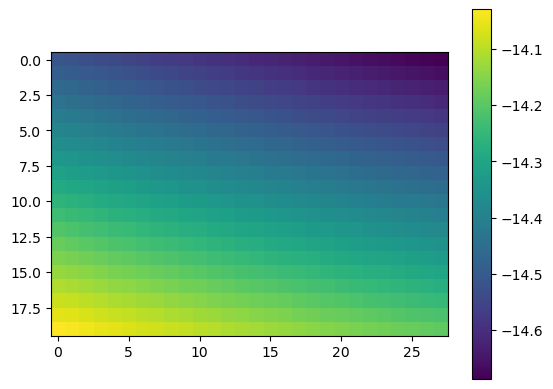

In [37]:
plt.imshow(ve_pred)
plt.colorbar()

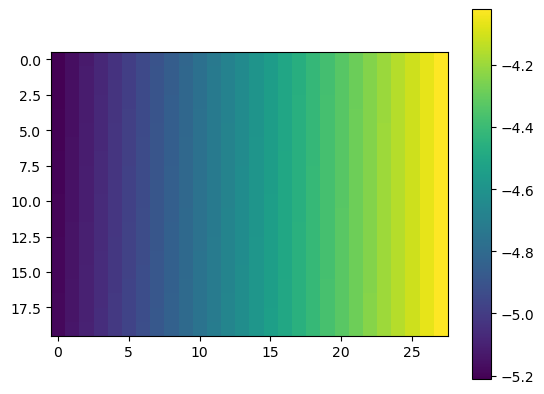

In [38]:
plt.imshow(vn_pred)
plt.colorbar()

In [39]:
get_model_per_frame(frame_id)

2025-09-17 10:45:51 | venti                | INFO     | Loading DISP frame database from /u/aurora-r0/govorcin/01_OPERA/VLM/Venti/data/opera_disp_frame.geojson | taskName=Task-3 | message=Loading DISP frame database from /u/aurora-r0/govorcin/01_OPERA/VLM/Venti/data/opera_disp_frame.geojson | asctime=2025-09-17 10:45:51
2025-09-17 10:45:55 | venti                | INFO     | Selected frame 3060 | taskName=Task-3 | message=Selected frame 3060 | asctime=2025-09-17 10:45:55
2025-09-17 10:45:55 | venti                | INFO     | Projected to EPSG:32614 for grid generation | taskName=Task-3 | message=Projected to EPSG:32614 for grid generation | asctime=2025-09-17 10:45:55
2025-09-17 10:45:55 | venti                | INFO     | Bounds: 230731, 4095471, 513608, 4299276 | taskName=Task-3 | message=Bounds: 230731, 4095471, 513608, 4299276 | asctime=2025-09-17 10:45:55
2025-09-17 10:45:55 | venti                | INFO     | Grid dimensions: 28 x 20 points | taskName=Task-3 | message=Grid dimen